# Classification Lab

Now that we have discussed the many classification techniques, it is time for us to try them in practice.
We will use the the dataset of toxins and toxin target database ([T3DB](https://www.t3db.ca/)) to classify whether organic compounds are carcinogenic or not. Let's continue working with the same code we had before and try to establish these structure-property relationships

In [1]:
try:
    import google.colab
    IN_COLAB = True
    !git clone https://github.com/dskoda/ml4mat-26s-public.git
    !cd ml4mat-26s-public && pip install . && cd ..
    !pip install xgboost
    !pip install mordred
    ROOT = "https://raw.githubusercontent.com/dskoda/ml4mat-26s-public/refs/heads/main/lectures/06-Kernels"
    STYLE = "colab"
except:
    IN_COLAB = False
    ROOT = "."
    STYLE = "jupyter"

fatal: destination path 'ml4mat-26s-public' already exists and is not an empty directory.
Processing /content/ml4mat-26s-public
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ml4mat_ucla: filename=ml4mat_ucla-26.3.31-py3-none-any.whl size=11998 sha256=f57ebbc067143f61a0bacc32d0c90af0aaf3befa337d30d05cbd37fa876a845f
  Stored in directory: /root/.cache/pip/wheels/94/9d/4a/b4663adad4a42ccfc8463d948e4ea267b8da41d102a21f0bab
Successfully built ml4mat_ucla
  Attempting uninstall: ml4mat_ucla
    Found existing installation: ml4mat_ucla 26.3.31
    Uninstalling ml4mat_ucla-26.3.31:
      Successfully uninstalled ml4mat_ucla-26.3.31


In [2]:
import re
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

# scikit-learn uses a lot of tools that we want
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# RDKit tools
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw

# Mordred to generate molecular descriptors
from mordred import Calculator, descriptors

import ml4mat_ucla as m4m

plt.style.use(STYLE)
m4m.utils.set_dpi(200)

## Loading and cleaning the dataset of toxicity of materials

I have uploaded already the dataset of toxicity of the molecules to make this easier. The dataset contains a lot of information, which you can look at using the `df.head()` analysis:

In [3]:
df = pd.read_json(f"{ROOT}/data/toxins.json.gz")
df.head()

,id,title,common_name,description,cas,pubchem_id,chemical_formula,weight,appearance,melting_point,...,chembl_id,chemspider_id,biodb_id,synthesis_reference,structure_image_caption,synonyms_list,types,cellular_locations,tissues,pathways
0,2,T3D0001,Arsenic,Arsenic(As) is a ubiquitous metalloid found in...,7440-38-2,104734,As,74.921600,Grey metallic solid.,> 615°C,...,,94549,None,None,None,Arsenic ion\r\nArsenic(3+)\r\nArsenic(3+) ion\...,"[{'id': 1, 'type_name': 'Inorganic Compound', ...","[{'id': 1, 'name': 'Cytoplasm', 'created_at': ...",[],[]
1,3,T3D0002,Lead,Lead is a soft and malleable heavy and post-tr...,7439-92-1,73212,Pb,207.976654,"Bluish-white metallic solid, turns grey when e...",327.5°C,...,,65967,None,None,None,Lead (II) cation\r\nLead ion\r\nLead ion (Pb2+...,"[{'id': 1, 'type_name': 'Inorganic Compound', ...","[{'id': 1, 'name': 'Cytoplasm', 'created_at': ...",[],[]
2,4,T3D0003,Mercury,Mercury is a metal that is a liquid at room te...,7439-97-6,26623,Hg,201.970642,Silver metallic liquid.,-38.8°C,...,,24800,None,None,None,Hg(2+)\r\nHg2+\r\nMercuric ion\r\nMercury ion\...,"[{'id': 1, 'type_name': 'Inorganic Compound', ...","[{'id': 1, 'name': 'Cytoplasm', 'created_at': ...",[],[]
3,5,T3D0004,Vinyl chloride,"Vinyl chloride is a man-made organic compound,...",75-01-4,6338,C2H3Cl,61.992330,"Colorless gas, usually stored as a liquid.",-153.7°C,...,None,None,None,,None,Chloroethene\r\nChloroethylene\r\nMonochloroet...,"[{'id': 7, 'type_name': 'Organic Compound', 'c...","[{'id': 1, 'name': 'Cytoplasm', 'created_at': ...",[],[]
4,7,T3D0006,Benzene,"Benzene is a toxic, volatile, flammable liquid...",71-43-2,241,C6H6,78.046950,Colorless liquid.,5.5°C,...,CHEMBL277500,236,None,"Copisarow, Maurice; Long, Cyril N H. The Fried...",None,Annulene\r\nAromatic alkane\r\nBenzeen\r\nBenz...,"[{'id': 7, 'type_name': 'Organic Compound', 'c...","[{'id': 1, 'name': 'Cytoplasm', 'created_at': ...","[{'id': 4, 'name': 'Bone Marrow', 'created_at'...",[]


The data is not fully clean, so we have to deal with it a bit. Specifically, we use the original data to see if something is organic, if it is carcinogenic, and just get floating-point numbers (e.g., remove the deg C)

In [4]:
def is_carcinogenic(txt):
    if txt is None:
        return np.nan

    if "carcinogenic to humans" in txt:
        return True

    if "possibly carcinogenic" in txt:
        return True

    if "probably carcinogenic" in txt:
        return True

    if "3, not classifiable" in txt:
        return False

    if "No indication" in txt:
        return False

    return np.nan

def is_organic(types):
    for t in types:
        if t["type_name"] == "Inorganic Compound":
            return False

        if t["type_name"] == "Organic Compound":
            return True

    return False

def get_float(txt):
    if type(txt) != str:
        return np.nan

    matches = re.findall("[0-9]+", txt)
    if len(matches) > 0:
        return float(matches[0])

    return np.nan

In [5]:
df["is_organic"] = df["types"].apply(is_organic)
df["is_carcinogenic"] = df["carcinogenicity"].apply(is_carcinogenic)
df["melting_point"] = df["melting_point"].apply(get_float)
df["boiling_point"] = df["boiling_point"].apply(get_float)

Now, because we have so much information that is not needed, now we limit ourselves to a dataset of organic compounds that contain enough data about them:

In [6]:
relevant_cols = [
    "id",
    "common_name",
    "cas",
    "weight",
    "moldb_smiles",
    "moldb_inchikey",
    "melting_point",
    "boiling_point",
    "is_carcinogenic",
]

org = df.loc[
    (df["is_organic"])
    & (~df["is_carcinogenic"].isna())
    & (~df["moldb_smiles"].isna())
    & (~df["moldb_smiles"].isna())
].reset_index(drop=True)
org = org[relevant_cols]

Let's quickly check the dataset size and how many compounds are carcinogenic there:

In [7]:
frac_positive = org["is_carcinogenic"].sum() / len(org)

print(f"{frac_positive * 100:.0f}% of the {len(org)} compounds are carcinogenic")

23% of the 2720 compounds are carcinogenic


Therefore, the dataset is not balanced.

## Featurizing the dataset

To do any kind of supervised learning, we have to featurize our dataset.
Doing this requires creating molecules from the SMILES, which can be tricky sometimes.
Therefore, we clean up the dataset a bit more by removing the molecules that do not make much sense or cannot be created:

In [8]:
# Creating the mols
mols = [Chem.MolFromSmiles(smi) for smi in org["moldb_smiles"]]

# removing the molecules that are None
indices = list(range(len(org)))
remove = [i for i, mol in enumerate(mols) if mol is None]
indices = list(set(indices) - set(remove))

# updating the list
mols = [mols[i] for i in indices]
org = org.iloc[indices]

[19:19:38] WARNING: not removing hydrogen atom without neighbors
[19:19:38] WARNING: not removing hydrogen atom without neighbors
[19:19:38] WARNING: not removing hydrogen atom without neighbors
[19:19:38] Explicit valence for atom # 7 O, 3, is greater than permitted
[19:19:38] Explicit valence for atom # 6 Al, 6, is greater than permitted
[19:19:38] Explicit valence for atom # 2 Al, 4, is greater than permitted
[19:19:38] Explicit valence for atom # 9 C, 5, is greater than permitted


Finally, we can compute the descriptors using `mordred`:

In [9]:
calc = Calculator(descriptors, ignore_3D=True)
desc = calc.pandas(mols)

 14%|█▍        | 386/2716 [01:06<05:26,  7.14it/s]

/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 15%|█▍        | 407/2716 [01:40<48:08,  1.25s/it]  

/usr/local/lib/python3.12/dist-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 23%|██▎       | 612/2716 [02:12<04:28,  7.83it/s][19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
[19:21:52] WARNING: not removing hydrogen atom without neighbors
 48%|████▊     | 1299/2716 [03:48<19:22,  1.22it/s]

/usr/local/lib/python3.12/dist-packages/mordred/_matrix_attributes.py:251: RuntimeWarning: invalid value encountered in scalar power
  s += (eig.vec[i, eig.max] * eig.vec[j, eig.max]) ** -0.5


100%|██████████| 2716/2716 [09:02<00:00,  5.00it/s]


Again, we have to clean the features - specifically, discarding the structures that failed somehow.
After discarding the features, we still end up with a pretty decent number of features for our dataset:

In [10]:
to_remove = []

for i in range(len(desc)):
    for name, feat in desc.iloc[i].items():
        if not type(feat) in [int, float, np.int64, np.float64]:
            to_remove.append(name)

features = desc[[col for col in desc.columns if not col in to_remove]]

In [22]:
features

,nAcid,nBase,nAromAtom,nAromBond,nAtom,nHeavyAtom,nSpiro,nBridgehead,nHetero,nH,nB,nC,nN,nO,nS,nP,nF,nCl,nBr,nI,nX,ATS0dv,ATS1dv,ATS2dv,ATS3dv,ATS4dv,ATS5dv,ATS6dv,ATS7dv,ATS8dv,ATS0d,ATS1d,ATS2d,ATS3d,ATS4d,ATS5d,ATS6d,ATS7d,ATS8d,ATS0Z,ATS1Z,ATS2Z,ATS3Z,ATS4Z,ATS5Z,ATS6Z,ATS7Z,ATS8Z,ATS0m,ATS1m,ATS2m,ATS3m,ATS4m,ATS5m,ATS6m,ATS7m,ATS8m,ATS0v,ATS1v,ATS2v,ATS3v,ATS4v,ATS5v,ATS6v,ATS7v,ATS8v,ATS0pe,ATS1pe,ATS2pe,ATS3pe,ATS4pe,ATS5pe,ATS6pe,ATS7pe,ATS8pe,ATS0p,ATS1p,ATS2p,ATS3p,ATS4p,ATS5p,ATS6p,ATS7p,ATS8p,ATS0i,ATS1i,ATS2i,ATS3i,ATS4i,ATS5i,ATS6i,ATS7i,ATS8i,AATS0dv,AATS1dv,AATS0d,AATS1d,AATS0Z,AATS1Z,AATS0m,AATS1m,AATS0v,AATS1v,AATS0pe,AATS1pe,AATS0p,AATS1p,AATS0i,AATS1i,ATSC0dv,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC0d,ATSC1d,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC0Z,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC0m,ATSC1m,ATSC2m,ATSC3m,ATSC4m,ATSC5m,ATSC6m,ATSC7m,ATSC8m,ATSC0v,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC0pe,ATSC1pe,ATSC2pe,ATSC3pe,ATSC4pe,ATSC5pe,ATSC6pe,ATSC7pe,ATSC8pe,ATSC0p,ATSC1p,ATSC2p,ATSC3p,ATSC4p,ATSC5p,ATSC6p,ATSC7p,ATSC8p,ATSC0i,ATSC1i,ATSC2i,ATSC3i,ATSC4i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC0dv,AATSC1dv,AATSC0d,AATSC1d,AATSC0Z,AATSC1Z,AATSC0m,AATSC1m,AATSC0v,AATSC1v,AATSC0pe,AATSC1pe,AATSC0p,AATSC1p,AATSC0i,AATSC1i,MATS1Z,MATS1m,MATS1v,MATS1pe,MATS1p,MATS1i,GATS1Z,GATS1m,GATS1v,GATS1pe,GATS1p,GATS1i,BalabanJ,BertzCT,nBonds,nBondsO,nBondsS,nBondsD,nBondsT,nBondsA,nBondsM,nBondsKS,nBondsKD,C1SP1,C2SP1,C1SP2,C2SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xch-5d,Xch-6d,Xch-7d,Xch-3dv,Xch-4dv,Xch-5dv,Xch-6dv,Xch-7dv,Xc-3d,Xc-4d,Xc-5d,Xc-6d,Xc-3dv,Xc-4dv,Xc-5dv,Xc-6dv,Xpc-4d,Xpc-5d,Xpc-6d,Xpc-4dv,Xpc-5dv,Xpc-6dv,Xp-1d,Xp-2d,Xp-3d,Xp-4d,Xp-5d,Xp-6d,Xp-7d,Xp-1dv,Xp-2dv,Xp-3dv,Xp-4dv,Xp-5dv,Xp-6dv,Xp-7dv,SZ,Sm,Sv,Spe,Sp,Si,MZ,Mm,Mv,Mpe,Mp,Mi,NsLi,NssBe,NssssBe,NssBH,NsssB,NssssB,NsCH3,NdCH2,NssCH2,NtCH,NdsCH,NaaCH,NsssCH,NddC,NtsC,NdssC,NaasC,NaaaC,NssssC,NsNH3,NsNH2,NssNH2,NdNH,NssNH,NaaNH,NtN,NsssNH,NdsN,NaaN,NsssN,NddsN,NaasN,NssssN,NsOH,NdO,NssO,NaaO,NsF,NsSiH3,NssSiH2,NsssSiH,NssssSi,NsPH2,NssPH,NsssP,NdsssP,NsssssP,NsSH,NdS,NssS,NaaS,NdssS,NddssS,NsCl,NsGeH3,NssGeH2,NsssGeH,NssssGe,NsAsH2,NssAsH,NsssAs,NsssdAs,NsssssAs,NsSeH,NdSe,NssSe,NaaSe,NdssSe,NddssSe,NsBr,NsSnH3,NssSnH2,NsssSnH,NssssSn,NsI,NsPbH3,NssPbH2,NsssPbH,NssssPb,SsLi,SssBe,SssssBe,SssBH,SsssB,SssssB,SsCH3,SdCH2,SssCH2,StCH,SdsCH,SaaCH,SsssCH,SddC,StsC,SdssC,SaasC,SaaaC,SssssC,SsNH3,SsNH2,SssNH2,SdNH,SssNH,SaaNH,StN,SsssNH,SdsN,SaaN,SsssN,SddsN,SaasN,SssssN,SsOH,SdO,SssO,SaaO,SsF,SsSiH3,SssSiH2,SsssSiH,SssssSi,SsPH2,SssPH,SsssP,SdsssP,SsssssP,SsSH,SdS,SssS,SaaS,SdssS,SddssS,SsCl,SsGeH3,SssGeH2,SsssGeH,SssssGe,SsAsH2,SssAsH,SsssAs,SsssdAs,SsssssAs,SsSeH,SdSe,SssSe,SaaSe,SdssSe,SddssSe,SsBr,SsSnH3,SssSnH2,SsssSnH,SssssSn,SsI,SsPbH3,SssPbH2,SsssPbH,SssssPb,ECIndex,fragCpx,fMF,nHBAcc,nHBDon,IC0,IC1,IC2,IC3,IC4,IC5,TIC0,TIC1,TIC2,TIC3,TIC4,TIC5,SIC0,SIC1,SIC2,SIC3,SIC4,SIC5,BIC0,BIC1,BIC2,BIC3,BIC4,BIC5,CIC0,CIC1,CIC2,CIC3,CIC4,CIC5,MIC0,MIC1,MIC2,MIC3,MIC4,MIC5,ZMIC0,ZMIC1,ZMIC2,ZMIC3,ZMIC4,ZMIC5,FilterItLogS,VMcGowan,LabuteASA,PEOE_VSA1,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA1,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,SlogP_VSA10,SlogP_VSA11,EState_VSA1,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,EState_VSA10,VSA_EState1,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,MPC2,MPC3,MPC4,MPC5,MPC6,MPC7,MPC8,MPC9,MPC10,TMPC10,piPC1,piPC2,piPC3,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,piPC10,TpiPC10,apol,bpol,nRing,n3Ring,n4Ring,n5Ring,n6Ring,n7Ring,n8Ring,n9Ring,n10Ring,n11Ring,n12Ring,nG12Ring,nHRing,n3HRing,n4HRing,n5HRing,n6HRing,n7HRing,n8HRing,n9HRing,n1

## Training models

Finally, we can train the models.

**Your goal is to train and evaluate the performance of a series of different models**.
Compare them against the metrics we discussed in the previous lecture and in the lecture.

Feel free to ask the instructor if you have any questions!

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "logistic": LogisticRegression(),
    "SVC": SVC(),
    "tree": DecisionTreeClassifier(),
    "rf": RandomForestClassifier(),
    "knns": KNeighborsClassifier(),
    "xgboost": XGBClassifier()
}

First I would like to compute a similarity metric for the molecules. I will convert the SMILES strings into molecular fingerprints. There are a lot of features already, so it is surprising this is not included.

In [20]:
pd.set_option('display.max_columns', None)
features.head()

,nAcid,nBase,nAromAtom,nAromBond,nAtom,nHeavyAtom,nSpiro,nBridgehead,nHetero,nH,nB,nC,nN,nO,nS,nP,nF,nCl,nBr,nI,nX,ATS0dv,ATS1dv,ATS2dv,ATS3dv,ATS4dv,ATS5dv,ATS6dv,ATS7dv,ATS8dv,ATS0d,ATS1d,ATS2d,ATS3d,ATS4d,ATS5d,ATS6d,ATS7d,ATS8d,ATS0Z,ATS1Z,ATS2Z,ATS3Z,ATS4Z,ATS5Z,ATS6Z,ATS7Z,ATS8Z,ATS0m,ATS1m,ATS2m,ATS3m,ATS4m,ATS5m,ATS6m,ATS7m,ATS8m,ATS0v,ATS1v,ATS2v,ATS3v,ATS4v,ATS5v,ATS6v,ATS7v,ATS8v,ATS0pe,ATS1pe,ATS2pe,ATS3pe,ATS4pe,ATS5pe,ATS6pe,ATS7pe,ATS8pe,ATS0p,ATS1p,ATS2p,ATS3p,ATS4p,ATS5p,ATS6p,ATS7p,ATS8p,ATS0i,ATS1i,ATS2i,ATS3i,ATS4i,ATS5i,ATS6i,ATS7i,ATS8i,AATS0dv,AATS1dv,AATS0d,AATS1d,AATS0Z,AATS1Z,AATS0m,AATS1m,AATS0v,AATS1v,AATS0pe,AATS1pe,AATS0p,AATS1p,AATS0i,AATS1i,ATSC0dv,ATSC1dv,ATSC2dv,ATSC3dv,ATSC4dv,ATSC5dv,ATSC6dv,ATSC7dv,ATSC8dv,ATSC0d,ATSC1d,ATSC2d,ATSC3d,ATSC4d,ATSC5d,ATSC6d,ATSC7d,ATSC8d,ATSC0Z,ATSC1Z,ATSC2Z,ATSC3Z,ATSC4Z,ATSC5Z,ATSC6Z,ATSC7Z,ATSC8Z,ATSC0m,ATSC1m,ATSC2m,ATSC3m,ATSC4m,ATSC5m,ATSC6m,ATSC7m,ATSC8m,ATSC0v,ATSC1v,ATSC2v,ATSC3v,ATSC4v,ATSC5v,ATSC6v,ATSC7v,ATSC8v,ATSC0pe,ATSC1pe,ATSC2pe,ATSC3pe,ATSC4pe,ATSC5pe,ATSC6pe,ATSC7pe,ATSC8pe,ATSC0p,ATSC1p,ATSC2p,ATSC3p,ATSC4p,ATSC5p,ATSC6p,ATSC7p,ATSC8p,ATSC0i,ATSC1i,ATSC2i,ATSC3i,ATSC4i,ATSC5i,ATSC6i,ATSC7i,ATSC8i,AATSC0dv,AATSC1dv,AATSC0d,AATSC1d,AATSC0Z,AATSC1Z,AATSC0m,AATSC1m,AATSC0v,AATSC1v,AATSC0pe,AATSC1pe,AATSC0p,AATSC1p,AATSC0i,AATSC1i,MATS1Z,MATS1m,MATS1v,MATS1pe,MATS1p,MATS1i,GATS1Z,GATS1m,GATS1v,GATS1pe,GATS1p,GATS1i,BalabanJ,BertzCT,nBonds,nBondsO,nBondsS,nBondsD,nBondsT,nBondsA,nBondsM,nBondsKS,nBondsKD,C1SP1,C2SP1,C1SP2,C2SP2,C3SP2,C1SP3,C2SP3,C3SP3,C4SP3,FCSP3,Xch-3d,Xch-4d,Xch-5d,Xch-6d,Xch-7d,Xch-3dv,Xch-4dv,Xch-5dv,Xch-6dv,Xch-7dv,Xc-3d,Xc-4d,Xc-5d,Xc-6d,Xc-3dv,Xc-4dv,Xc-5dv,Xc-6dv,Xpc-4d,Xpc-5d,Xpc-6d,Xpc-4dv,Xpc-5dv,Xpc-6dv,Xp-1d,Xp-2d,Xp-3d,Xp-4d,Xp-5d,Xp-6d,Xp-7d,Xp-1dv,Xp-2dv,Xp-3dv,Xp-4dv,Xp-5dv,Xp-6dv,Xp-7dv,SZ,Sm,Sv,Spe,Sp,Si,MZ,Mm,Mv,Mpe,Mp,Mi,NsLi,NssBe,NssssBe,NssBH,NsssB,NssssB,NsCH3,NdCH2,NssCH2,NtCH,NdsCH,NaaCH,NsssCH,NddC,NtsC,NdssC,NaasC,NaaaC,NssssC,NsNH3,NsNH2,NssNH2,NdNH,NssNH,NaaNH,NtN,NsssNH,NdsN,NaaN,NsssN,NddsN,NaasN,NssssN,NsOH,NdO,NssO,NaaO,NsF,NsSiH3,NssSiH2,NsssSiH,NssssSi,NsPH2,NssPH,NsssP,NdsssP,NsssssP,NsSH,NdS,NssS,NaaS,NdssS,NddssS,NsCl,NsGeH3,NssGeH2,NsssGeH,NssssGe,NsAsH2,NssAsH,NsssAs,NsssdAs,NsssssAs,NsSeH,NdSe,NssSe,NaaSe,NdssSe,NddssSe,NsBr,NsSnH3,NssSnH2,NsssSnH,NssssSn,NsI,NsPbH3,NssPbH2,NsssPbH,NssssPb,SsLi,SssBe,SssssBe,SssBH,SsssB,SssssB,SsCH3,SdCH2,SssCH2,StCH,SdsCH,SaaCH,SsssCH,SddC,StsC,SdssC,SaasC,SaaaC,SssssC,SsNH3,SsNH2,SssNH2,SdNH,SssNH,SaaNH,StN,SsssNH,SdsN,SaaN,SsssN,SddsN,SaasN,SssssN,SsOH,SdO,SssO,SaaO,SsF,SsSiH3,SssSiH2,SsssSiH,SssssSi,SsPH2,SssPH,SsssP,SdsssP,SsssssP,SsSH,SdS,SssS,SaaS,SdssS,SddssS,SsCl,SsGeH3,SssGeH2,SsssGeH,SssssGe,SsAsH2,SssAsH,SsssAs,SsssdAs,SsssssAs,SsSeH,SdSe,SssSe,SaaSe,SdssSe,SddssSe,SsBr,SsSnH3,SssSnH2,SsssSnH,SssssSn,SsI,SsPbH3,SssPbH2,SsssPbH,SssssPb,ECIndex,fragCpx,fMF,nHBAcc,nHBDon,IC0,IC1,IC2,IC3,IC4,IC5,TIC0,TIC1,TIC2,TIC3,TIC4,TIC5,SIC0,SIC1,SIC2,SIC3,SIC4,SIC5,BIC0,BIC1,BIC2,BIC3,BIC4,BIC5,CIC0,CIC1,CIC2,CIC3,CIC4,CIC5,MIC0,MIC1,MIC2,MIC3,MIC4,MIC5,ZMIC0,ZMIC1,ZMIC2,ZMIC3,ZMIC4,ZMIC5,FilterItLogS,VMcGowan,LabuteASA,PEOE_VSA1,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,SMR_VSA1,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,SlogP_VSA10,SlogP_VSA11,EState_VSA1,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,EState_VSA10,VSA_EState1,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,MPC2,MPC3,MPC4,MPC5,MPC6,MPC7,MPC8,MPC9,MPC10,TMPC10,piPC1,piPC2,piPC3,piPC4,piPC5,piPC6,piPC7,piPC8,piPC9,piPC10,TpiPC10,apol,bpol,nRing,n3Ring,n4Ring,n5Ring,n6Ring,n7Ring,n8Ring,n9Ring,n10Ring,n11Ring,n12Ring,nG12Ring,nHRing,n3HRing,n4HRing,n5HRing,n6HRing,n7HRing,n8HRing,n9HRing,n1

In [21]:
from rdkit import DataStructs
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

morgan_gen = GetMorganGenerator(radius=2, fpSize=1024)

fingerprints = []
for mol in mols:
    # Generate Morgan fingerprint using MorganGenerator
    fp = morgan_gen.GetFingerprint(mol)
    # Convert bit vector to a numpy array of integers (0s and 1s)
    arr = np.zeros((1,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fingerprints.append(arr)

# Create a DataFrame from the fingerprints, naming columns appropriately
morgan_features = pd.DataFrame(fingerprints, columns=[f"Morgan_{i}" for i in range(1024)])

# Ensure indices align before concatenation and update the features DataFrame
features2 = pd.concat([features.reset_index(drop=True), morgan_features], axis=1)


New shape of features dataset: (2716, 757)


In [27]:
X = features2.values
y = np.array(org["is_carcinogenic"].values).astype(int)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=85, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name in ['logistic', 'SVC', 'knns']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Evaluate metrics
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

    # Conditionally format roc_auc based on its type
    roc_auc_str = f"{roc_auc:.4f}" if isinstance(roc_auc, float) else str(roc_auc)
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC AUC: {roc_auc_str}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)


Training logistic...
logistic - Accuracy: 0.8971, Precision: 0.7787, Recall: 0.7661, F1-score: 0.7724, ROC AUC: 0.9050

Training SVC...
SVC - Accuracy: 0.9136, Precision: 0.9639, Recall: 0.6452, F1-score: 0.7729, ROC AUC: N/A

Training tree...
tree - Accuracy: 0.8676, Precision: 0.6940, Recall: 0.7500, F1-score: 0.7209, ROC AUC: 0.8262

Training rf...
rf - Accuracy: 0.9136, Precision: 0.9231, Recall: 0.6774, F1-score: 0.7814, ROC AUC: 0.9164

Training knns...
knns - Accuracy: 0.8401, Precision: 0.6259, Recall: 0.7419, F1-score: 0.6790, ROC AUC: 0.8977

Training xgboost...
xgboost - Accuracy: 0.9246, Precision: 0.9029, Recall: 0.7500, F1-score: 0.8194, ROC AUC: 0.9039


,accuracy,precision,recall,f1_score,roc_auc
logistic,0.897059,0.778689,0.766129,0.772358,0.905012
SVC,0.913603,0.963855,0.645161,0.772947,N/A
tree,0.867647,0.69403,0.75,0.72093,0.82619
rf,0.913603,0.923077,0.677419,0.781395,0.916417
knns,0.840074,0.62585,0.741935,0.678967,0.897677
xgboost,0.924632,0.902913,0.75,0.819383,0.903936


To quantify the models, I printed the confusion matrix of the models with the best f1 score.

Top 3 models by F1-score:


,accuracy,precision,recall,f1_score,roc_auc
xgboost,0.924632,0.902913,0.75,0.819383,0.903936
rf,0.913603,0.923077,0.677419,0.781395,0.916417
SVC,0.913603,0.963855,0.645161,0.772947,N/A


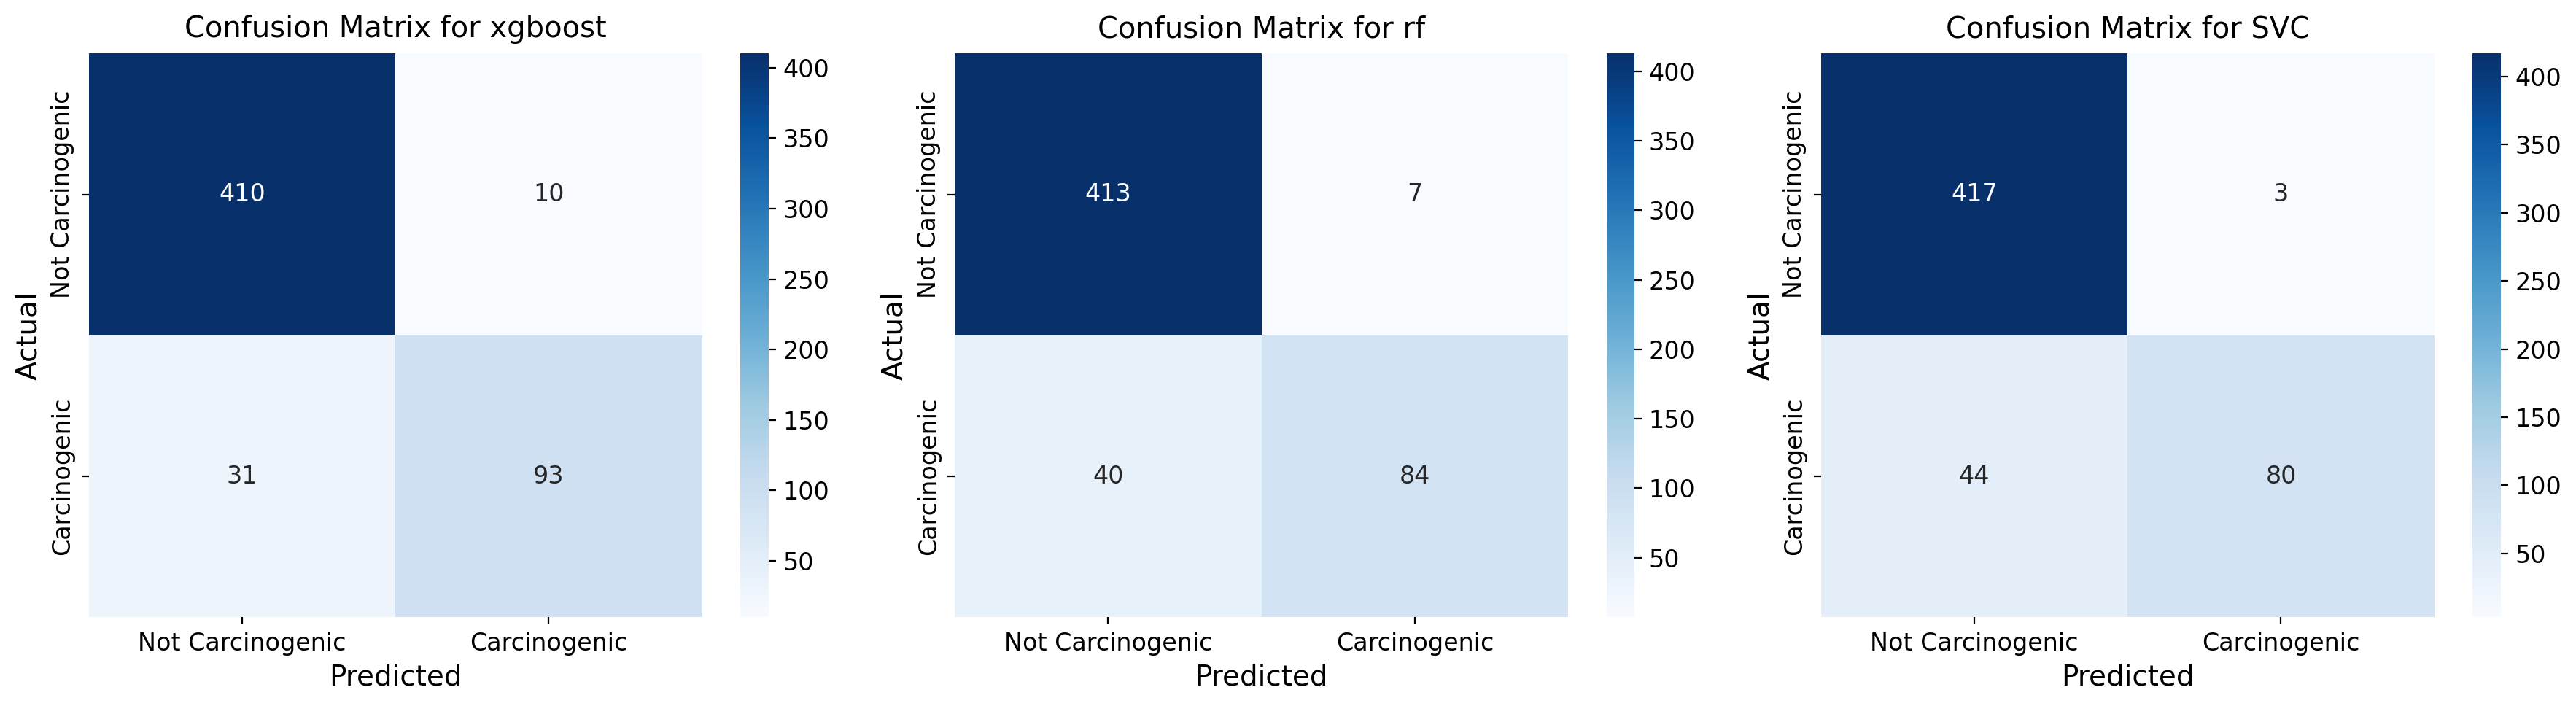

In [30]:
# Get the top 3 models based on F1-score
top_3_models = results_df.sort_values(by='f1_score', ascending=False).head(3)

print("Top 3 models by F1-score:")
display(top_3_models)

plt.figure(figsize=(18, 5))

for i, (name, row) in enumerate(top_3_models.iterrows()):
    model = models[name]

    # Determine which test set to use (scaled or unscaled)
    if name in ['logistic', 'SVC', 'knns']:
        X_test_for_prediction = X_test_scaled
    else:
        X_test_for_prediction = X_test

    # Make predictions
    y_pred = model.predict(X_test_for_prediction)

    # Compute confusion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Carcinogenic', 'Carcinogenic'],
                yticklabels=['Not Carcinogenic', 'Carcinogenic'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

Let's see if the added molecular fingerprint helped at all by retraining these models and checking if the f1scores have changed.

In [31]:
X = features.values
y = np.array(org["is_carcinogenic"].values).astype(int)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=85, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    if name in ['logistic', 'SVC', 'knns']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    # Evaluate metrics
    accuracy = metrics.accuracy_score(y_test, y_pred)
    precision = metrics.precision_score(y_test, y_pred)
    recall = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    roc_auc = metrics.roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

    # Conditionally format roc_auc based on its type
    roc_auc_str = f"{roc_auc:.4f}" if isinstance(roc_auc, float) else str(roc_auc)
    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}, ROC AUC: {roc_auc_str}")

# Display all results in a DataFrame for easy comparison
results_df = pd.DataFrame(results).T
display(results_df)


Training logistic...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


logistic - Accuracy: 0.8860, Precision: 0.7672, Recall: 0.7177, F1-score: 0.7417, ROC AUC: 0.9025

Training SVC...
SVC - Accuracy: 0.9136, Precision: 0.9753, Recall: 0.6371, F1-score: 0.7707, ROC AUC: N/A

Training tree...
tree - Accuracy: 0.8529, Precision: 0.6667, Recall: 0.7097, F1-score: 0.6875, ROC AUC: 0.8025

Training rf...
rf - Accuracy: 0.9099, Precision: 0.8866, Recall: 0.6935, F1-score: 0.7783, ROC AUC: 0.9209

Training knns...
knns - Accuracy: 0.8805, Precision: 0.7611, Recall: 0.6935, F1-score: 0.7257, ROC AUC: 0.8922

Training xgboost...
xgboost - Accuracy: 0.9136, Precision: 0.8738, Recall: 0.7258, F1-score: 0.7930, ROC AUC: 0.9100


,accuracy,precision,recall,f1_score,roc_auc
logistic,0.886029,0.767241,0.717742,0.741667,0.902496
SVC,0.913603,0.975309,0.637097,0.770732,N/A
tree,0.852941,0.666667,0.709677,0.6875,0.802458
rf,0.909926,0.886598,0.693548,0.778281,0.920929
knns,0.880515,0.761062,0.693548,0.725738,0.892224
xgboost,0.913603,0.873786,0.725806,0.792952,0.909965


Top 3 models by F1-score:


,accuracy,precision,recall,f1_score,roc_auc
xgboost,0.913603,0.873786,0.725806,0.792952,0.909965
rf,0.909926,0.886598,0.693548,0.778281,0.920929
SVC,0.913603,0.975309,0.637097,0.770732,N/A


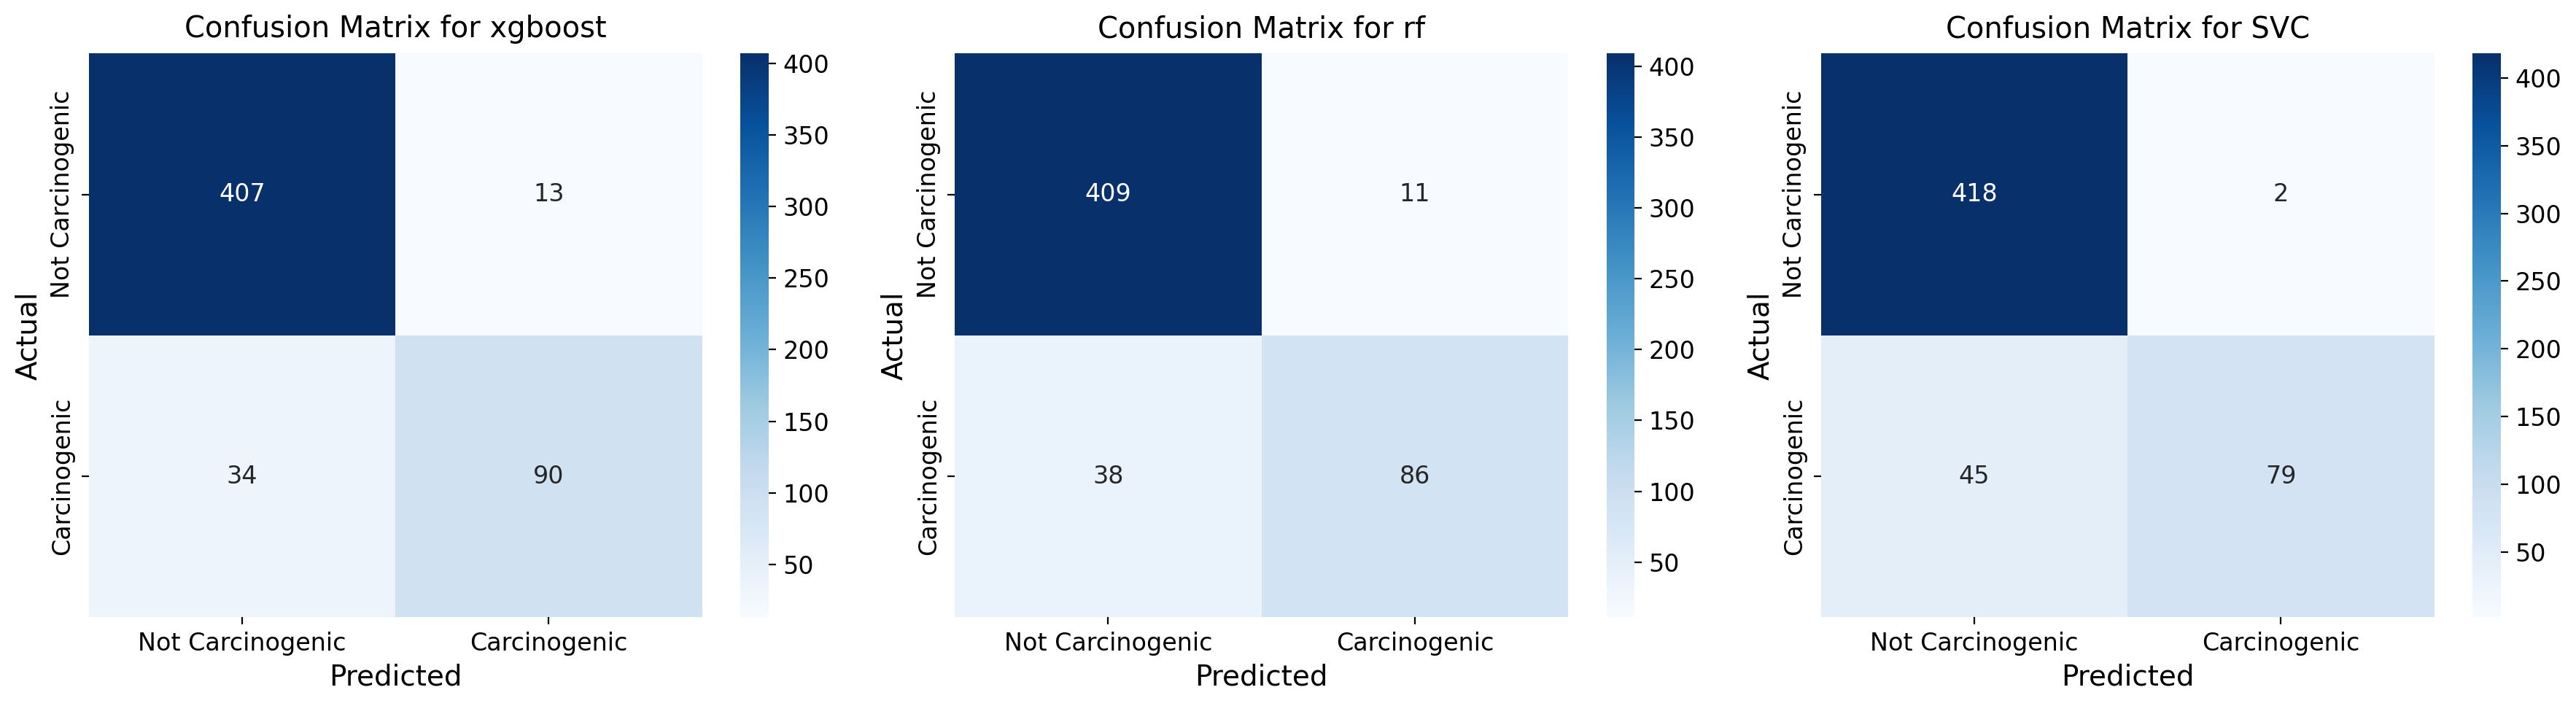

In [33]:
# Get the top 3 models based on F1-score
top_3_models = results_df.sort_values(by='f1_score', ascending=False).head(3)

print("Top 3 models by F1-score:")
display(top_3_models)

plt.figure(figsize=(18, 5))

for i, (name, row) in enumerate(top_3_models.iterrows()):
    model = models[name]

    # Determine which test set to use (scaled or unscaled)
    if name in ['logistic', 'SVC', 'knns']:
        X_test_for_prediction = X_test_scaled
    else:
        X_test_for_prediction = X_test

    # Make predictions
    y_pred = model.predict(X_test_for_prediction)

    # Compute confusion matrix
    cm = metrics.confusion_matrix(y_test, y_pred)

    plt.subplot(1, 3, i + 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Carcinogenic', 'Carcinogenic'],
                yticklabels=['Not Carcinogenic', 'Carcinogenic'])
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')


plt.tight_layout()
plt.show()

### Conclusions
It is good to note that the f1scores generally increase with the additional molecular fingerprints by around a hundredth of a point. While this is not that much, especially considering the cost of opening the dataset, it may indicate that a more robust kernal for molecular similarity (albeit there is already a lot of metrics embedded) helps improve the predictive aspect of the models.

The models are quite good at predicting if a molecule are a carcinogen, although the highest recall was only 75% which is concerning if this was an actual scientific endeavor.
$$ Recall = \frac{True\ Positive}{True\ Positive + False\ Negative} $$
This means that a quarter of all carcinogens made it through screening, likely because the dataset was so assymmetric to train mainly if something wasn't a carcinogen. This is reflected in a much higher accuracy of nearly 0.92 for a lot of the models.

An area of interest for future work is to see if better training can occur if the dataset is actually balanced to have an equal number of carcinogens as well as noncarcinogens, and furthermore by possibly calculating Tanimoto similarity between a set of known carcinogens.